# Problemas de distribución de probabilidad

## Distribución binomial

En teoría de la probabilidad y estadística, la distribución binomial es la distribución de probabilidad discreta que da sólo dos resultados posibles en un experimento; por ejemplo, al lanzar una moneda, puede salir cara o cruz.

In [ ]:
from scipy.stats import binom

# Definir todas las funciones de probabilidad relacionadas con esta distribución.

def dbinom(x, size, prob = 0.5):
    """
    Calcula la estimación puntual de la distribución binomial.
    """
    result = binom.pmf(k = x, n = size, p = prob, loc = 0)

    return result

def pbinom(q, size, prob = 0.5):
    """
    Calcula el acumulado de la distribución binomial.
    """
    result = binom.cdf(k = q, n = size, p = prob, loc = 0)

    return result

def qbinom(p, size, prob = 0.5):
    """
    Calcula la función cuantil a partir de la distribución binomial.
    """
    result = binom.ppf(q = p, n = size, p = prob, loc = 0)

    return result

def rbinom(n, size, prob = 0.5):
    """
    Genera variables aleatorias a partir de la distribución binomial.
    """
    result = binom.rvs(n = size, p = prob, size = n)

    return result

In [ ]:
# Distribución binomial(10, 0.2), dónde n = 10 es el número de ensayos y p = 0.2 es la probabilidad de éxito en un solo ensayo
import numpy as np

np.random.seed(42)

print(f"Probability that a Binomial(10, 0.2) takes the value 2: {dbinom(2, size = 10, prob = 0.2)}")
print(f"Probability that a Binomial(10, 0.2) will take a value less than 2: {pbinom(2, size = 10, prob = 0.2)}")
print(f"Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? {qbinom(0.9, size = 10, prob = 0.2)}")
print(f"Generate 2000 random values from a Binomial(10, 0.2) distribution: {rbinom(2000, size = 10, prob = 0.2)}")

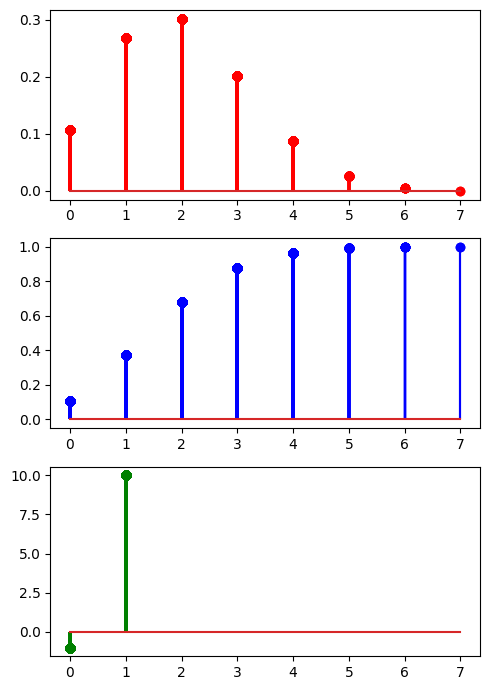

In [ ]:
import matplotlib.pyplot as plt

np.random.seed(42)

size = 10
prob = 0.2
data = rbinom(2000, size = 10, prob = 0.2)

pmf = dbinom(data, size = size, prob = prob)
cdf = pbinom(data, size = size, prob = prob)
ppf = qbinom(data, size = size, prob = prob)

fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].stem(data, pmf, "r-")
axis[1].stem(data, cdf, "b-")
axis[2].stem(data, ppf, "g-")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

## Ejercicio 1

Escriba las funciones anteriores pero para distribuciones normales y uniformes.

In [4]:
from scipy.stats import norm, uniform
import numpy as np

# --- DISTRIBUCIÓN NORMAL ---

def dnorm(x, mean=0, sd=1):
    # Estimación puntual (PDF)
    return norm.pdf(x, loc=mean, scale=sd)

def pnorm(q, mean=0, sd=1):
    # Acumulado (CDF)
    return norm.cdf(q, loc=mean, scale=sd)

def qnorm(p, mean=0, sd=1):
    # Función cuantil (PPF)
    return norm.ppf(p, loc=mean, scale=sd)

def rnorm(n, mean=0, sd=1):
    # Generación de variables aleatorias
    return norm.rvs(loc=mean, scale=sd, size=n)

# --- DISTRIBUCIÓN UNIFORME ---

def dunif(x, min=0, max=1):
    # Estimación puntual (PDF)
    # Nota: scale en scipy es (max - min)
    return uniform.pdf(x, loc=min, scale=max - min)

def punif(q, min=0, max=1):
    # Acumulado (CDF)
    return uniform.cdf(q, loc=min, scale=max - min)

def qunif(p, min=0, max=1):
    # Función cuantil (PPF)
    return uniform.ppf(p, loc=min, scale=max - min)

def runif(n, min=0, max=1):
    # Generación de variables aleatorias
    return uniform.rvs(loc=min, scale=max - min, size=n)

# Asegúrate de que la definición coincida con la llamada
def punif(q, min_val=0, max_val=1):
    return uniform.cdf(q, loc=min_val, scale=max_val - min_val)

# Ahora la llamada funcionará sin error
print(f"Probabilidad Uniforme en 5: {punif(5, min_val=0, max_val=10)}")

Probabilidad Uniforme en 5: 0.5


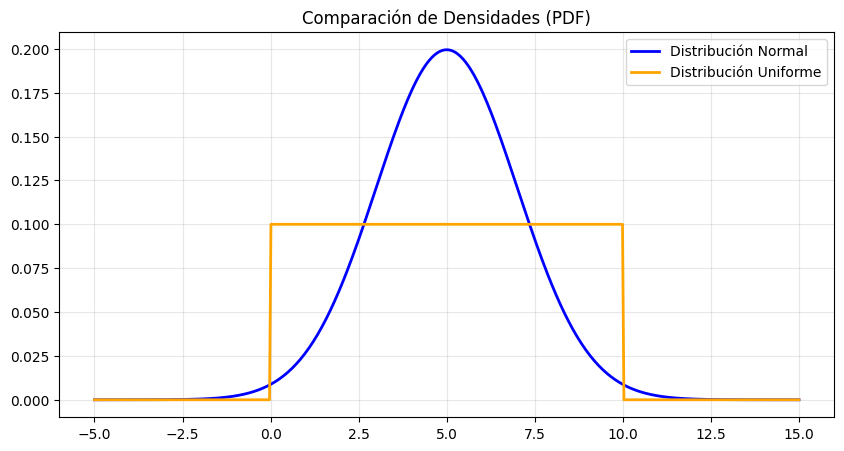

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generar datos (Eje X)
x = np.linspace(-5, 15, 500)

# 2. Obtener densidades
y_norm = dnorm(x, mean=5, sd=2)
y_unif = dunif(x, min_val=0, max_val=10)

# 3. Crear el lienzo
fig, ax = plt.subplots(figsize=(10, 5))

# 4. Dibujar
ax.plot(x, y_norm, label="Distribución Normal", color="blue", lw=2)
ax.plot(x, y_unif, label="Distribución Uniforme", color="orange", lw=2)

# 5. Estética y leyenda
ax.set_title("Comparación de Densidades (PDF)")
ax.legend()
ax.grid(True, alpha=0.3)

# 6. FORZAR LA MUESTRA (Vital para que aparezca)
plt.show()
